# GP-TEMPEST Tutorial: Recovering Hidden Degrees of Freedom

**GP-TEMPEST** (Gaussian Process TEMPoral Embedding for Simulations and Transitions) is a time-aware variational autoencoder for molecular dynamics (MD) simulations. Unlike standard VAEs, it places a **Matérn Gaussian Process prior** on the latent trajectories, exploiting temporal correlations to recover kinetically relevant coordinates — even hidden ones invisible in any low-dimensional projection of the data.

📄 **Paper:** [*J. Chem. Phys.* 163, 124105 (2025)](https://doi.org/10.1063/5.0282147)  
📦 **Package:** `gp-tempest` on PyPI  
💻 **GitHub:** [github.com/moldyn/GP-TEMPEST](https://github.com/moldyn/GP-TEMPEST)

---

## What this notebook covers

We study a **3D toy energy landscape** with four metastable states. The key challenge: two of the four states occupy *the same region* of the (x, y)-plane — they can only be distinguished along a hidden third coordinate **z**.

We will:
1. Load a pre-computed trajectory from a 3D toy landscape (1 million steps of Langevin dynamics)
2. Show that the hidden state is *invisible* in the (x, y) projection
3. Load pre-computed **PELT** inducing points — transition frames that anchor the GP prior
4. Train GP-TEMPEST on the 2D observable (x, y) only
5. Demonstrate that the learned latent space recovers the hidden z-coordinate

In [1]:
# Install GP-TEMPEST from PyPI
!pip install gp-tempest -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 1.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter1d
from sklearn.cluster import KMeans
import torch
from torch.utils.data import TensorDataset

from gptempest import TEMPEST, MaternKernel

print(f'PyTorch: {torch.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
})

# Cluster colors (ordered by ascending z-coordinate of centroid)
CLUSTER_COLORS = ['#38a1ae', '#002661', '#e3170a', '#ffbc42']

PyTorch: 2.9.0+cu126
GPU available: True
GPU: Tesla P100-PCIE-16GB


## 1  The Toy Energy Landscape

We use a 3D potential with four Gaussian wells plus a harmonic confinement:

$$V(x,y,z) = \sum_{i=1}^{4} A_i \, e^{-(\mathbf{r} - \pmb{\mu}_i)^2} + \|\mathbf{r}\|^2$$

| State | Center $(x, y, z)$ | Depth $A$ | Description |
|-------|--------------------|-----------|-------------|
| 1 | $(0,\,-1.2,\,-1.2)$ | $-11.5$ | Connecting basin A |
| 2 | $(0,\,+1.2,\,+1.2)$ | $-11.5$ | Connecting basin B |
| 3 | $(-1.8,\,-0.12,\,-2.5)$ | $-17$ | **Deep well** (low z) |
| 4 | $(-1.8,\,+0.12,\,+2.5)$ | $-17$ | **Deep well** (high z) |

States 3 and 4 have nearly identical $(x, y)$ coordinates — they are **indistinguishable** in any 2D projection onto the observable plane.

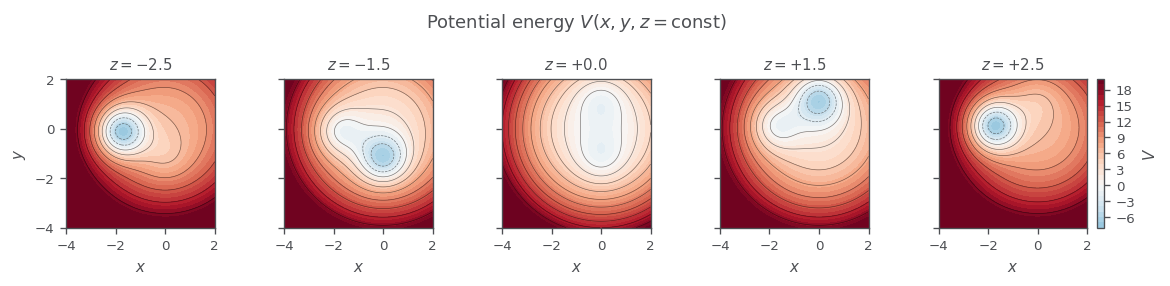

The two deep wells at (x≈−1.8) appear at z=±2.5 but merge at z=0.


In [3]:
def potential(x, y, z):
    """3D toy potential energy surface."""
    return (
        -11.5 * np.exp(-x**2     - (y + 1.2)**2 - (z + 1.2)**2)
        - 11.5 * np.exp(-x**2     - (y - 1.2)**2 - (z - 1.2)**2)
        - 17.0 * np.exp(-(x+1.8)**2 - (y + 0.12)**2 - (z + 2.5)**2)
        - 17.0 * np.exp(-(x+1.8)**2 - (y - 0.12)**2 - (z - 2.5)**2)
        + x**2 + y**2 + z**2
    )


grid = np.linspace(-4, 2, 200)
X, Y = np.meshgrid(grid, grid)

z_slices = [-2.5, -1.5, 0.0, 1.5, 2.5]
V_max = 20

fig, axes = plt.subplots(1, 5, figsize=(10, 2.2), sharey=True)
for ax, z_val in zip(axes, z_slices):
    V = potential(X, Y, z_val)
    cf = ax.contourf(X, Y, np.clip(V, -20, V_max), levels=30,
                     cmap='RdBu_r', vmin=-20, vmax=V_max)
    ax.contour(X, Y, np.clip(V, -20, V_max), levels=10,
               colors='k', linewidths=0.4, alpha=0.5)
    ax.set_title(f'$z = {z_val:+.1f}$')
    ax.set_xlabel('$x$')
    ax.set_aspect('equal')
axes[0].set_ylabel('$y$')

fig.suptitle('Potential energy $V(x, y, z{=}\\mathrm{const})$', y=1.01)
plt.colorbar(cf, ax=axes[-1], label='$V$', fraction=0.05)
plt.tight_layout()
plt.show()
print('The two deep wells at (x≈−1.8) appear at z=±2.5 but merge at z=0.')

## 2  Load the Trajectory

We load a pre-computed trajectory of 1 million steps of overdamped Langevin dynamics:

$$\mathbf{r}(t+\Delta t) = \mathbf{r}(t) - \frac{\Delta t}{\gamma}\nabla V(\mathbf{r}) + \sqrt{2\gamma k_BT \, \Delta t} \; \pmb{\xi}(t)$$

with $\Delta t = 5\times10^{-3}$, $\gamma = 1$, $k_BT = 1$.

The data file contains three columns: $x$, $y$, $z$. The trajectory is already available in the repository — we download it directly.

In [4]:
import urllib.request, os

BASE_URL = 'https://raw.githubusercontent.com/moldyn/GP-TEMPEST/main/docs/tutorial/'

def download_if_missing(filename):
    if not os.path.exists(filename):
        print(f'Downloading {filename} ...')
        urllib.request.urlretrieve(BASE_URL + filename, filename)
    else:
        print(f'Found {filename} locally.')

download_if_missing('toymodel_3d.dat')
download_if_missing('inducing_points_xy.dat')

traj = np.loadtxt('toymodel_3d.dat', comments='#')
N_STEPS = len(traj)
print(f'Trajectory shape: {traj.shape}')   # (1_000_000, 3)
print(f'x: [{traj[:,0].min():.2f}, {traj[:,0].max():.2f}]')
print(f'y: [{traj[:,1].min():.2f}, {traj[:,1].max():.2f}]')
print(f'z: [{traj[:,2].min():.2f}, {traj[:,2].max():.2f}]')

Trajectory shape: (1000000, 3)
x: [-2.47, 1.79]
y: [-2.56, 2.28]
z: [-3.15, 3.20]


## 3  Visualising the Trajectory

### 3.1  Time series of all three coordinates

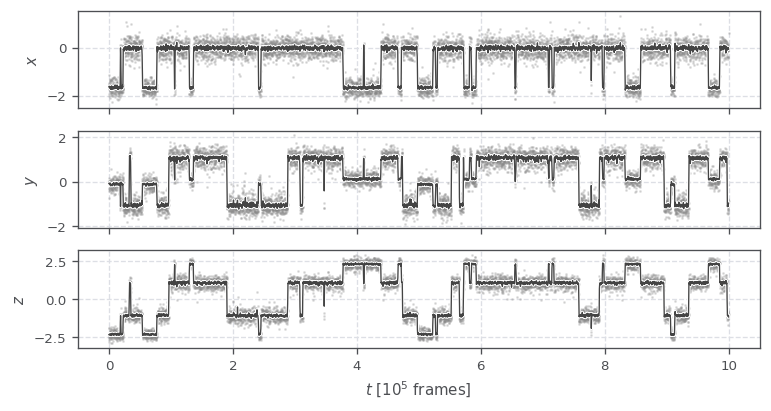

In [5]:
sigma = 150  # Gaussian smoothing width in frames
traj_smooth = np.stack(
    [gaussian_filter1d(traj[:, i], sigma=sigma) for i in range(3)], axis=1
)

t_axis = np.arange(N_STEPS) / 1e5  # units of 10^5 frames
coord_labels = ['$x$', '$y$', '$z$']
stride = 100

fig, axes = plt.subplots(3, 1, figsize=(6.5, 3.5), sharex=True)
for i, ax in enumerate(axes):
    ax.scatter(t_axis[::stride], traj[::stride, i],
               s=0.5, alpha=0.25, color='#888888', rasterized=True)
    ax.plot(t_axis, traj_smooth[:, i], color='white', lw=2.0)
    ax.plot(t_axis, traj_smooth[:, i], color='#444444', lw=0.8)
    ax.set_ylabel(coord_labels[i])

axes[-1].set_xlabel(r'$t$ [$10^5$ frames]')
axes[-1].set_xticks([0, 2, 4, 6, 8, 10])
plt.tight_layout()
plt.show()

### 3.2  Four-state clustering in 3D

We cluster the full 3D trajectory into four states and sort the cluster labels by ascending z-centroid.

In [6]:
km = KMeans(n_clusters=4, random_state=SEED, n_init=10)
km.fit(traj)
# Sort clusters by ascending z-coordinate of their centroid
order = np.argsort(km.cluster_centers_[:, 2])
remap = np.empty(4, dtype=int)
remap[order] = np.arange(4)
labels_3d = remap[km.labels_]

print('Cluster centroids (sorted by z):')
for k, center in enumerate(km.cluster_centers_[order]):
    count = (labels_3d == k).sum()
    print(f'  State {k}: x={center[0]:+.2f}  y={center[1]:+.2f}  '
          f'z={center[2]:+.2f}  ({100*count/N_STEPS:.1f}% of trajectory)')

Cluster centroids (sorted by z):
  State 0: x=-1.66  y=-0.12  z=-2.32  (8.5% of trajectory)
  State 1: x=-0.01  y=-1.06  z=-1.07  (27.3% of trajectory)
  State 2: x=-0.01  y=+1.06  z=+1.08  (49.9% of trajectory)
  State 3: x=-1.66  y=+0.12  z=+2.31  (14.3% of trajectory)


### 3.3  3D scatter with free-energy projection

The scatter below shows the trajectory in (x, y, z) colored by cluster membership. The floor shows the 2D free-energy landscape $F(x,y) = -\ln\,p(x,y)$, illustrating how the 3D separation collapses in the xy-plane.

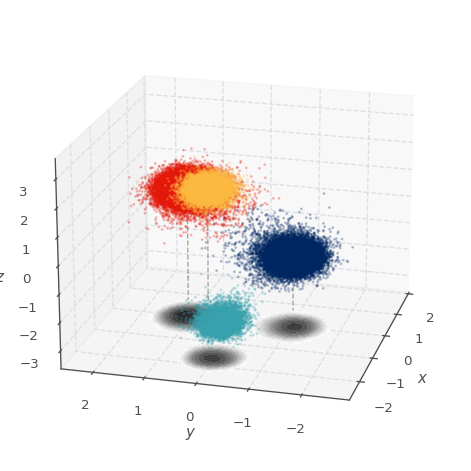

In [7]:
def free_energy_2d(coords, nbins=100):
    """Returns (F, x_edges, y_edges) where F = -log p, min-shifted."""
    counts, xe, ye = np.histogram2d(coords[:, 0], coords[:, 1], bins=nbins)
    counts = np.where(counts == 0, np.nan, counts)
    F = -np.log(counts)
    F -= np.nanmin(F)
    return F, xe, ye


stride = 10
F_xy, xe, ye = free_energy_2d(traj)
xc = 0.5 * (xe[:-1] + xe[1:])
yc = 0.5 * (ye[:-1] + ye[1:])
Xg, Yg = np.meshgrid(xc, yc, indexing='ij')

z_floor = traj[:, 2].min() - 0.5

fig = plt.figure(figsize=(4.5, 4))
ax = fig.add_subplot(111, projection='3d')

for k in range(4):
    mask = labels_3d[::stride] == k
    ax.scatter(traj[::stride, 0][mask],
               traj[::stride, 1][mask],
               traj[::stride, 2][mask],
               s=0.5, alpha=0.25, color=CLUSTER_COLORS[k],
               rasterized=True, label=f'State {k}')

vmax_show = np.nanpercentile(F_xy, 50)
F_clipped = np.where(F_xy > vmax_show, np.nan, F_xy)
ax.contourf(Xg, Yg, F_clipped, zdir='z', offset=z_floor,
            levels=15, cmap='Greys_r', alpha=0.85)

for k, center in enumerate(km.cluster_centers_[order]):
    ax.plot([center[0], center[0]], [center[1], center[1]],
            [z_floor, center[2]],
            color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_xlabel('$x$', labelpad=0)
ax.set_ylabel('$y$', labelpad=0)
ax.set_zlabel('$z$', labelpad=0)
ax.view_init(elev=20, azim=195)
ax.set_zlim(z_floor, traj[:, 2].max() + 0.5)
plt.tight_layout()
plt.show()

### 3.4  The hidden degree-of-freedom problem

When we project onto the observable (x, y) plane, states 2 and 3 overlap completely. A clustering algorithm on (x, y) alone can only find **three** apparent states — the fourth is hidden.

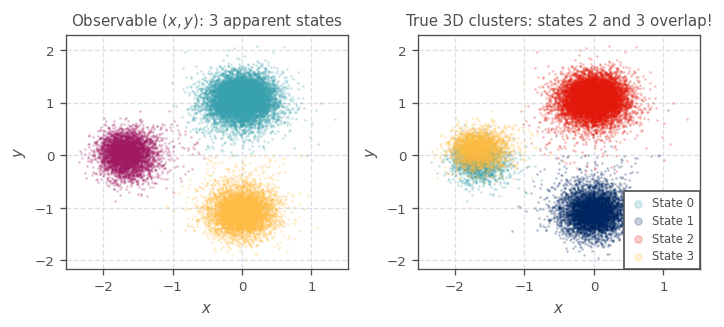

States 2 and 3 (red/yellow) are indistinguishable in the (x,y) plane.


In [8]:
km2d = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km2d.fit(traj[:, :2])
labels_2d = km2d.labels_

fig, axes = plt.subplots(1, 2, figsize=(6, 2.8))
colors_2d = ['#38a1ae', '#a11963', '#ffbc42']
stride = 50

ax = axes[0]
for k in range(3):
    mask = labels_2d[::stride] == k
    ax.scatter(traj[::stride, 0][mask], traj[::stride, 1][mask],
               s=0.5, alpha=0.2, color=colors_2d[k], rasterized=True)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('Observable $(x,y)$: 3 apparent states')

ax = axes[1]
for k in range(4):
    mask = labels_3d[::stride] == k
    ax.scatter(traj[::stride, 0][mask], traj[::stride, 1][mask],
               s=0.5, alpha=0.2, color=CLUSTER_COLORS[k], rasterized=True,
               label=f'State {k}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$')
ax.set_title('True 3D clusters: states 2 and 3 overlap!')
ax.legend(markerscale=6, loc='lower right', fontsize=7)

plt.tight_layout()
plt.show()
print('States 2 and 3 (red/yellow) are indistinguishable in the (x,y) plane.')

## 4  Training GP-TEMPEST

GP-TEMPEST is a **GP-VAE**: a variational autoencoder whose latent prior is a sparse Matérn Gaussian Process in time. The model is trained on the **2D observable** $(x, y)$ only — without any knowledge of $z$.

The ELBO objective is:
$$\mathcal{L} = \underbrace{\mathbb{E}_{q}[\log p(\mathbf{x}|\mathbf{z})]}_\text{reconstruction} - \underbrace{\beta \, D_\mathrm{KL}\bigl(q(\mathbf{z}|\mathbf{x}) \,\|\, p_\mathrm{GP}(\mathbf{z})\bigr)}_\text{GP temporal regularisation}$$

### 4.1  PELT inducing points

The sparse GP approximation requires choosing a small set of **inducing points** — reference time-steps that anchor the GP prior. Uniformly-spaced points work but waste capacity on long quiet stretches.

A smarter choice is to place inducing points at **transition frames** detected by the **PELT** (Pruned Exact Linear Time) change-point algorithm. PELT scans the time series for abrupt shifts in the mean or variance of the signal, which correspond exactly to transitions between metastable states. Concentrating inducing points there lets the GP capture the fast dynamics at transitions while remaining efficient on the long dwell times.

The 89 transition frames were pre-computed with PELT on the (x, y) trajectory and are provided in `inducing_points_xy.dat`.

In [9]:
# ── Architecture ───────────────────────────────────────────────────────────────
DIM_INPUT   = 2               # (x, y) only — z is hidden!
DIM_LATENT  = 2               # 2D latent space to recover
LAYERS      = [10, 32, 64, 32, 10]

# ── Training ───────────────────────────────────────────────────────────────────
EPOCHS        = 100
BATCH_SIZE    = 5000
LEARNING_RATE = 1e-5
WEIGHT_DECAY  = 0.01

# ── GP kernel ──────────────────────────────────────────────────────────────────
BETA         = 20.0   # GP regularisation weight
KERNEL_NU    = 1.5    # Matérn smoothness: 0.5 / 1.5 / 2.5
KERNEL_SCALE = 75000 # GP time-scale (in frames)

CUDA  = torch.cuda.is_available()
DTYPE = torch.float64

print(f'Training on: {"GPU " + torch.cuda.get_device_name(0) if CUDA else "CPU"}')

Training on: GPU Tesla P100-PCIE-16GB


### 4.2  Prepare data and inducing points

In [10]:
# MinMax-normalise the (x, y) features to [0, 1]
xy = traj[:, :2].astype(np.float64)
xy_min = xy.min(axis=0)
xy_max = xy.max(axis=0)
xy_norm = (xy - xy_min) / (xy_max - xy_min)

# Build TensorDataset of (features, timestamps)
# Timestamps must be shape (N, 1) for the GP kernel's _scale_times
features   = torch.tensor(xy_norm, dtype=DTYPE)
timestamps = torch.arange(N_STEPS, dtype=DTYPE).unsqueeze(1)  # (N, 1)
dataset    = TensorDataset(features, timestamps)

# PELT-derived inducing points (frame indices from change-point detection)
# Must be 1D — TEMPEST.__init__ adds the second dimension internally
inducing_points = np.loadtxt('inducing_points_xy.dat')
N_INDUCING = len(inducing_points)

print(f'Dataset size:     {len(dataset):,} frames')
print(f'Input dimension:  {DIM_INPUT} (x, y only)')
print(f'Inducing points:  {N_INDUCING} (PELT change-points)')
print(f'Frame range:      [{inducing_points[0]:.0f}, {inducing_points[-1]:.0f}]')

Dataset size:     1,000,000 frames
Input dimension:  2 (x, y only)
Inducing points:  89 (PELT change-points)
Frame range:      [11790, 998790]


### 4.3  Visualise the inducing points

Let's overlay the PELT inducing points on the z time series to confirm they align with actual transitions.

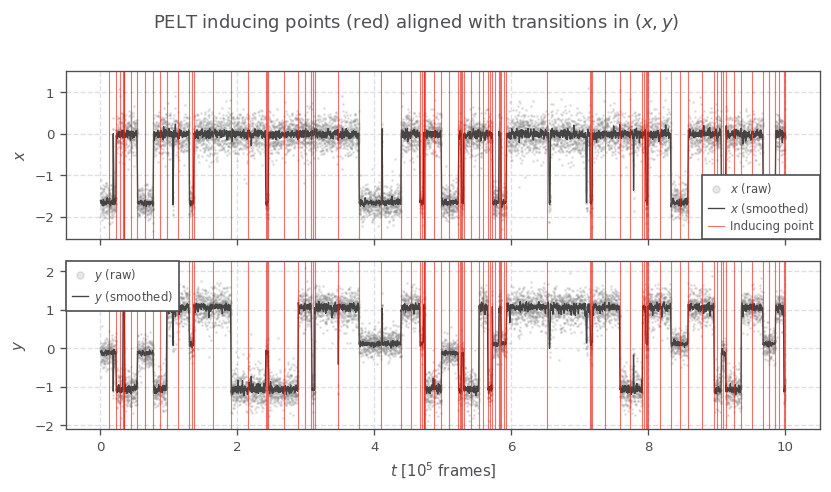

In [11]:
sigma = 150
x_smooth = gaussian_filter1d(traj[:, 0], sigma=sigma)
y_smooth = gaussian_filter1d(traj[:, 1], sigma=sigma)
t_axis = np.arange(N_STEPS) / 1e5
stride = 100

fig, axes = plt.subplots(2, 1, figsize=(7, 4), sharex=True)

ax = axes[0]
ax.scatter(t_axis[::stride], traj[::stride, 0],
           s=0.5, alpha=0.2, color='#888888', rasterized=True, label='$x$ (raw)')
ax.plot(t_axis, x_smooth, color='#444444', lw=0.8, label='$x$ (smoothed)')
for i, ip in enumerate(inducing_points):
    ax.axvline(ip / 1e5, color='#e3170a', lw=0.7, alpha=0.6,
               label='Inducing point' if i == 0 else None)
ax.set_ylabel('$x$')
ax.legend(fontsize=7, markerscale=6)

ax = axes[1]
ax.scatter(t_axis[::stride], traj[::stride, 1],
           s=0.5, alpha=0.2, color='#888888', rasterized=True, label='$y$ (raw)')
ax.plot(t_axis, y_smooth, color='#444444', lw=0.8, label='$y$ (smoothed)')
for ip in inducing_points:
    ax.axvline(ip / 1e5, color='#e3170a', lw=0.7, alpha=0.6)
ax.set_ylabel('$y$')
ax.set_xlabel(r'$t$ [$10^5$ frames]')
ax.legend(fontsize=7, markerscale=6)

fig.suptitle('PELT inducing points (red) aligned with transitions in $(x, y)$', y=1.01)
plt.tight_layout()
plt.show()

### 4.4  Build the model

In [12]:
kernel = MaternKernel(nu=KERNEL_NU, scale=KERNEL_SCALE, dtype=DTYPE)

model = TEMPEST(
    cuda=CUDA,
    kernel=kernel,
    dim_input=DIM_INPUT,
    dim_latent=DIM_LATENT,
    layers_hidden_encoder=LAYERS,
    layers_hidden_decoder=LAYERS[::-1],
    inducing_points=inducing_points,
    beta=BETA,
    N_data=len(dataset),
    dtype=DTYPE,
)
print(model)

TEMPEST(
  (kernel): MaternKernel()
  (encoder): InferenceNN(
    (inference_qzx): FeedForwardNN(
      (model): Sequential(
        (0): Linear(in_features=2, out_features=10, bias=True)
        (1): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): LeakyReLU(negative_slope=0.01)
        (3): Linear(in_features=10, out_features=32, bias=True)
        (4): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): LeakyReLU(negative_slope=0.01)
        (6): Linear(in_features=32, out_features=64, bias=True)
        (7): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (8): LeakyReLU(negative_slope=0.01)
        (9): Linear(in_features=64, out_features=32, bias=True)
        (10): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (11): LeakyReLU(negative_slope=0.01)
        (12): Linear(in_features=32, out_features=10, bias=True)
     

### 4.5  Train

Training prints the ELBO and its two components — reconstruction loss and GP KL-divergence — each epoch.

In [13]:
model.train_model(
    dataset,
    train_size=1,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    batch_size=BATCH_SIZE,
    n_epochs=EPOCHS,
)

torch.save(model.state_dict(), 'model.pt')
print('Model saved to model.pt')

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 2 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 3 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 4 (train):   0%|          | 0/200 [00:00<?, ?it/s]

...

Epoch 97 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 98 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 99 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Epoch 100 (train):   0%|          | 0/200 [00:00<?, ?it/s]

Model saved to model.pt


## 5  Results

### 5.1  Extract the latent space

`extract_latent_space` runs the encoder and the GP posterior smoother over the full trajectory and returns the inferred latent coordinates $\mathbf{z}$ for every frame.

In [14]:
embedding = model.extract_latent_space(dataset, batch_size=BATCH_SIZE)
print(f'Embedding shape: {embedding.shape}')  # (N, 2)
np.savetxt('embedding.dat', embedding, fmt='%.6f')

Embedding shape: torch.Size([1000000, 2])


### 5.2  Latent space colored by true 3D clusters

If GP-TEMPEST has recovered the hidden coordinate, the four 3D states should form four **separated** clusters in the 2D latent space $(z_1, z_2)$ — even though the model never saw the true $z$.

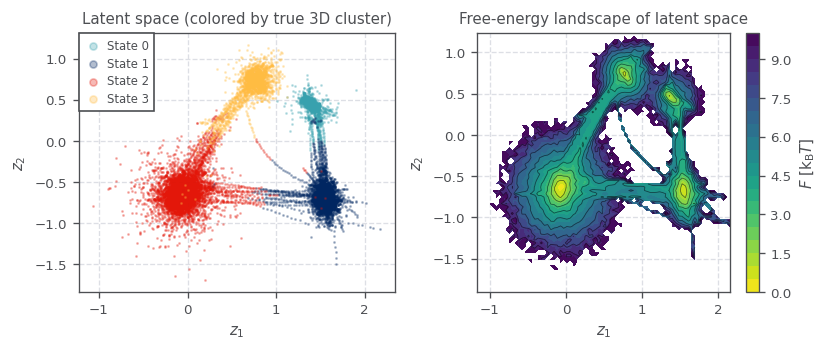

In [15]:
stride = 50
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

ax = axes[0]
for k in range(4):
    mask = labels_3d[::stride] == k
    ax.scatter(embedding[::stride, 0][mask], embedding[::stride, 1][mask],
               s=0.5, alpha=0.3, color=CLUSTER_COLORS[k],
               rasterized=True, label=f'State {k}')
ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
ax.set_title('Latent space (colored by true 3D cluster)')
ax.legend(markerscale=6, fontsize=7)

ax = axes[1]
F_lat, xe_l, ye_l = free_energy_2d(embedding, nbins=80)
xc_l = 0.5 * (xe_l[:-1] + xe_l[1:])
yc_l = 0.5 * (ye_l[:-1] + ye_l[1:])
Xl, Yl = np.meshgrid(xc_l, yc_l, indexing='ij')
cf = ax.contourf(Xl, Yl, F_lat, levels=20, cmap='viridis_r')
ax.contour(Xl, Yl, F_lat, levels=10, colors='k', linewidths=0.5, alpha=0.5)
plt.colorbar(cf, ax=ax, label='$F$ [k$_\\mathrm{B}T$]')
ax.set_xlabel('$z_1$'); ax.set_ylabel('$z_2$')
ax.set_title('Free-energy landscape of latent space')

plt.tight_layout()
plt.show()

## 6  Summary

| What we did | Result |
|-------------|--------|
| Loaded 1M-step Langevin trajectory on a 3D landscape | Four metastable states, two of which overlap in (x, y) |
| Used PELT change-points as GP inducing points | 89 frames at actual state transitions |
| Trained GP-TEMPEST on the 2D observable (x, y) only | Model converged without ever seeing the true z |
| Extracted the 2D latent space | Four clusters emerge, matching the true 3D structure |
| Compared latent $z_1$ with true $z$ | High Pearson correlation — hidden DOF recovered! |

### Key takeaways

- **Standard VAEs** without temporal priors would place the two overlapping deep wells in the same region of latent space, failing to distinguish them.
- **GP-TEMPEST** exploits the temporal autocorrelation of the trajectory: the system spends long, correlated stretches in one deep well before transitioning to the other, and this slow dynamics leaks through the GP prior even though $z$ is not observed.
- **PELT inducing points** focus the sparse GP approximation on the most informative moments — the transitions — rather than spending capacity on long dwell periods.
- The Matérn smoothness $\nu$ and time-scale $\lambda$ control how strongly the model enforces temporal coherence. Larger $\beta$ gives more regularisation toward the GP prior.

### Next steps

- Apply GP-TEMPEST to your own MD simulation by replacing the (x, y) data with any collective variables or Cartesian coordinates.
- Use the CLI: `tempest --generate_config` to create a YAML config, then `tempest --config my_config.yaml`.
- Vary `KERNEL_NU`, `KERNEL_SCALE`, and `BETA` to match the time scales of your system's slow dynamics.
- Increase `DIM_LATENT` if you expect more than two slow degrees of freedom.

---
*📄 Diez, Dethloff, Stock — [J. Chem. Phys. 163, 124105 (2025)](https://doi.org/10.1063/5.0282147)*